# UrbanSound8K Exploratory Data Analysis

**Research project:** Noise-Robust Urban Sound Classification

This notebook examines dataset integrity, class and fold balance, recording characteristics, clip duration, waveforms, Log-Mel spectrograms, and MFCCs. It uses the project's reusable dataset and audio modules so the analysis matches the later training pipeline.

## 1. Reproducible setup

Run this notebook with the project's activated `.venv`. Paths are discovered from `pyproject.toml`, so execution works from either the repository root or the `notebooks` directory.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

search_start = Path.cwd().resolve()
candidate_roots = [search_start, *search_start.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / 'pyproject.toml').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate the project root containing pyproject.toml.')

source_directory = PROJECT_ROOT / 'src'
if str(source_directory) not in sys.path:
    sys.path.insert(0, str(source_directory))

from urban_sound_robustness.audio import (
    AudioPreprocessor,
    MFCCFeatureExtractor,
    load_audio,
)
from urban_sound_robustness.datasets import (
    create_dataset_adapter,
    inspect_dataset,
    save_inspection_result,
)
from urban_sound_robustness.utils.config import load_experiment_config
from urban_sound_robustness.utils.paths import resolve_path_settings

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titleweight': 'bold',
})
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}')

Project root: repository root
PyTorch: 2.11.0+cu126


In [2]:
configuration = load_experiment_config(
    PROJECT_ROOT / 'configs' / 'experiment' / 'development.yaml'
)
path_settings = resolve_path_settings(
    configuration.section('paths'), configuration.project_root
)
dataset_settings = configuration.section('dataset')
audio_settings = configuration.section('audio')
adapter = create_dataset_adapter(dataset_settings, configuration.project_root)
records = adapter.load_records()

FIGURE_DIRECTORY = path_settings['results'] / 'figures' / 'eda'
METRIC_DIRECTORY = path_settings['results'] / 'metrics' / 'eda'
INSPECTION_DIRECTORY = path_settings['results'] / 'metrics' / 'dataset_inspection'
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
METRIC_DIRECTORY.mkdir(parents=True, exist_ok=True)

def save_figure(figure, file_name):
    output_path = FIGURE_DIRECTORY / file_name
    figure.savefig(output_path, bbox_inches='tight', facecolor='white')
    print(f'Saved: {output_path.relative_to(PROJECT_ROOT)}')
    return output_path

display(Markdown(
    f'''**Configured preprocessing decisions**

- Target sample rate: **{audio_settings['sample_rate']:,} Hz**
- Target duration: **{audio_settings['clip_duration_seconds']:.1f} seconds**
- Mono conversion: **{audio_settings['mono']}**
- Short clips: **trailing zero padding**
- Training crop: **{audio_settings['length_normalization']['training_crop']}**
- Evaluation crop: **{audio_settings['length_normalization']['evaluation_crop']}**
- Log-Mel bands: **{audio_settings['log_mel']['n_mels']}**
- MFCC coefficients: **{audio_settings['mfcc']['n_mfcc']}**
- Fold split: train **{dataset_settings['folds']['train']}**, validation **{dataset_settings['folds']['validation']}**, test **{dataset_settings['folds']['test']}**
'''
))

**Configured preprocessing decisions**

- Target sample rate: **22,050 Hz**
- Target duration: **4.0 seconds**
- Mono conversion: **True**
- Short clips: **trailing zero padding**
- Training crop: **random**
- Evaluation crop: **center**
- Log-Mel bands: **64**
- MFCC coefficients: **40**
- Fold split: train **[1, 2, 3, 4, 5, 6, 7, 8]**, validation **[9]**, test **[10]**


## 2. Dataset integrity and numerical inventory

The adapter validates UrbanSound8K-specific metadata. The reusable inspection layer reads lightweight audio headers to verify file readability, duration, sample rate, channels, and frame counts. Existing structured inspection files are reused when present.

In [3]:
required_inspection_files = [
    INSPECTION_DIRECTORY / 'summary.json',
    INSPECTION_DIRECTORY / 'class_distribution.csv',
    INSPECTION_DIRECTORY / 'fold_distribution.csv',
    INSPECTION_DIRECTORY / 'sample_rate_distribution.csv',
    INSPECTION_DIRECTORY / 'sample_inventory.csv',
]
if not all(path.is_file() for path in required_inspection_files):
    inspection_result = inspect_dataset(
        records, adapter.class_names, inspect_audio_headers=True, show_progress=True
    )
    save_inspection_result(inspection_result, INSPECTION_DIRECTORY)

with (INSPECTION_DIRECTORY / 'summary.json').open(encoding='utf-8') as file_handle:
    inspection_summary = json.load(file_handle)
class_distribution = pd.read_csv(INSPECTION_DIRECTORY / 'class_distribution.csv')
fold_distribution = pd.read_csv(INSPECTION_DIRECTORY / 'fold_distribution.csv')
sample_rate_distribution = pd.read_csv(INSPECTION_DIRECTORY / 'sample_rate_distribution.csv')
inventory = pd.read_csv(INSPECTION_DIRECTORY / 'sample_inventory.csv')

quality_table = pd.DataFrame({
    'measure': ['Samples', 'Classes', 'Folds', 'Missing files', 'Unreadable files', 'Total audio hours'],
    'value': [
        inspection_summary['total_samples'],
        inspection_summary['num_classes'],
        len(inspection_summary['folds']),
        inspection_summary['missing_file_count'],
        inspection_summary['unreadable_file_count'],
        round(inspection_summary['total_duration_hours'], 2),
    ],
})
display(quality_table)
display(Markdown(
    '**Observation.** The inventory contains **{total:,}** clips across **{classes}** classes and all ten official folds. There are **{missing} missing** and **{unreadable} unreadable** files, so the complete dataset is available for analysis.'.format(total=inspection_summary['total_samples'], classes=inspection_summary['num_classes'], missing=inspection_summary['missing_file_count'], unreadable=inspection_summary['unreadable_file_count'])
))

,measure,value
0,Samples,8732.00
1,Classes,10.00
2,Folds,10.00
3,Missing files,0.00
4,Unreadable files,0.00
5,Total audio hours,8.75


**Observation.** The inventory contains **8,732** clips across **10** classes and all ten official folds. There are **0 missing** and **0 unreadable** files, so the complete dataset is available for analysis.

## 3. Class distribution

Class counts reveal whether overall accuracy could be dominated by frequent categories. Macro-averaged metrics will later give every class equal importance.

Saved: results\figures\eda\01_class_distribution.png


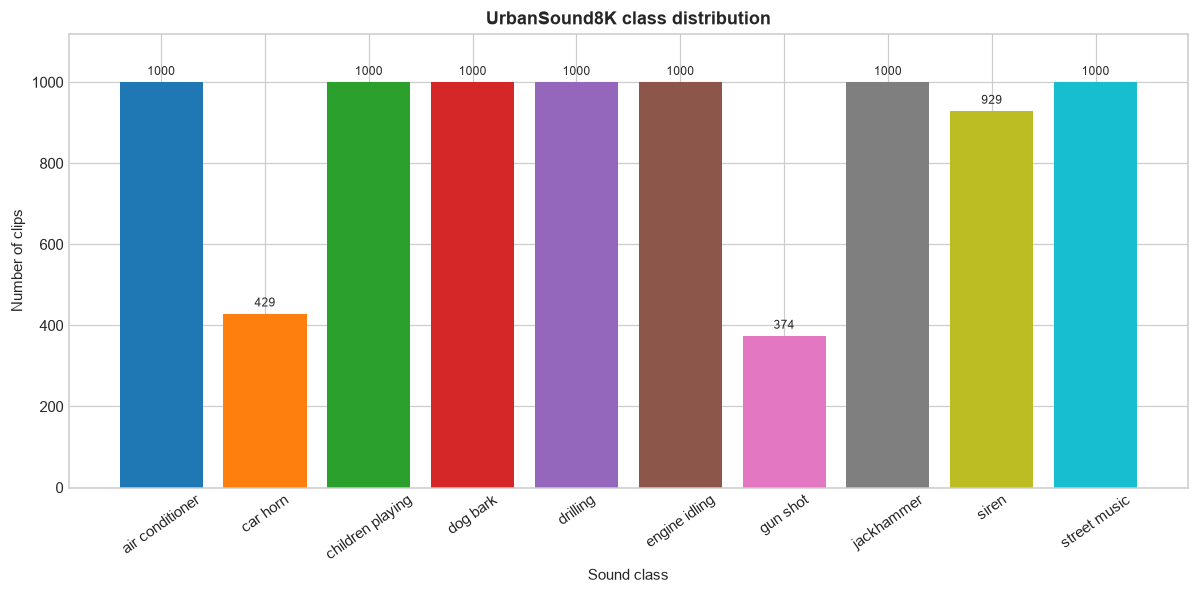

**Observation.** Counts range from **374** for *gun shot* to **1000** for *air conditioner* (ratio **2.67:1**). The imbalance is meaningful, so macro F1 and per-class metrics should accompany accuracy.

In [4]:
ordered_classes = list(adapter.class_names)
class_distribution['display_name'] = class_distribution['class_name'].str.replace('_', ' ')
figure, axis = plt.subplots(figsize=(11, 5.5))
bars = axis.bar(
    class_distribution['display_name'],
    class_distribution['sample_count'],
    color=plt.cm.tab10(np.linspace(0, 1, len(class_distribution))),
)
axis.bar_label(bars, padding=3, fontsize=8)
axis.set(title='UrbanSound8K class distribution', xlabel='Sound class', ylabel='Number of clips')
axis.tick_params(axis='x', rotation=35)
axis.set_ylim(0, class_distribution['sample_count'].max() * 1.12)
figure.tight_layout()
save_figure(figure, '01_class_distribution.png')
plt.show()

class_distribution.drop(columns='display_name').to_csv(
    METRIC_DIRECTORY / 'class_distribution.csv', index=False
)
smallest_class = class_distribution.loc[class_distribution['sample_count'].idxmin()]
largest_class = class_distribution.loc[class_distribution['sample_count'].idxmax()]
imbalance_ratio = largest_class['sample_count'] / smallest_class['sample_count']
display(Markdown(
    '**Observation.** Counts range from **{smallest_count}** for *{smallest_name}* to **{largest_count}** for *{largest_name}* (ratio **{ratio:.2f}:1**). The imbalance is meaningful, so macro F1 and per-class metrics should accompany accuracy.'.format(smallest_count=int(smallest_class['sample_count']), smallest_name=smallest_class['display_name'], largest_count=int(largest_class['sample_count']), largest_name=largest_class['display_name'], ratio=imbalance_ratio)
))

## 4. Fold distribution and leakage-aware split

UrbanSound8K folds group slices from the same source recording. Preserving them prevents closely related clips from leaking across training, validation, and test sets.

Saved: results\figures\eda\02_fold_distribution.png


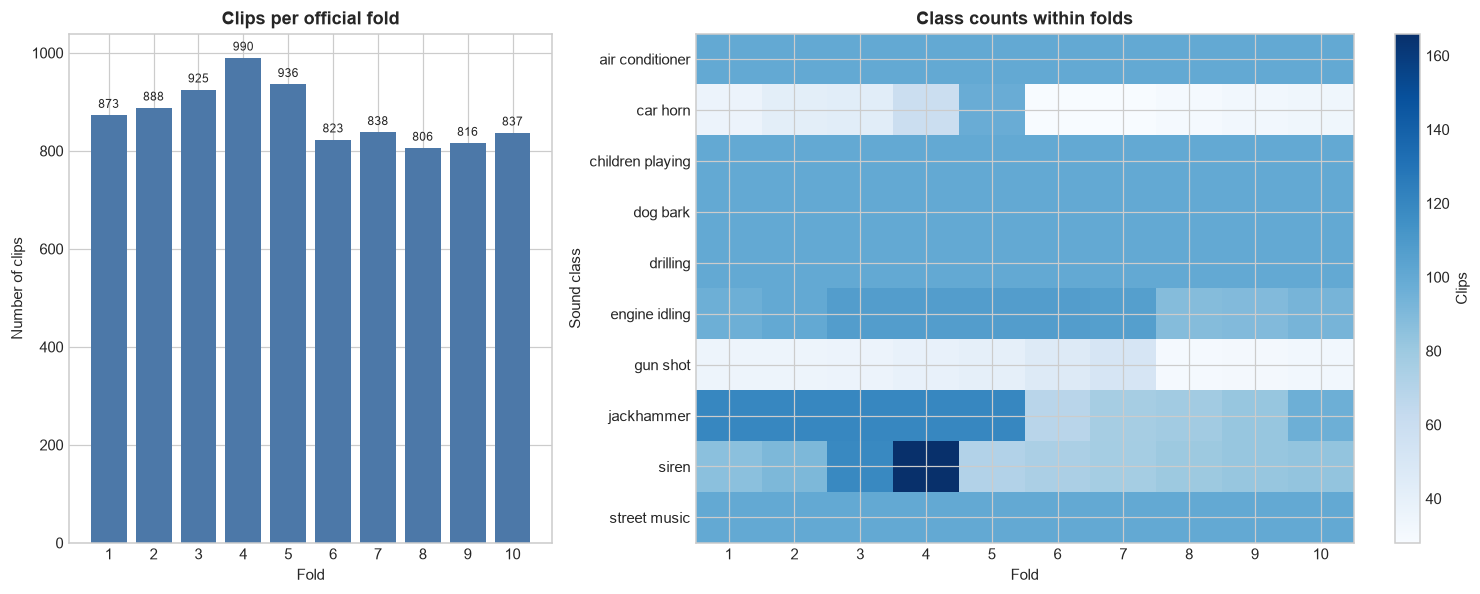

,split,sample_count
0,train,7079
1,validation,816
2,test,837


**Observation.** Official fold sizes range from **806** to **990** clips. The configured split contains **7,079 training**, **816 validation**, and **837 test** clips. Fold 10 remains untouched during model selection.

In [5]:
fold_class_counts = pd.crosstab(inventory['class_name'], inventory['fold']).reindex(ordered_classes)
figure, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1, 1.7]})
fold_bars = axes[0].bar(
    fold_distribution['fold'].astype(str),
    fold_distribution['sample_count'],
    color='#4C78A8',
)
axes[0].bar_label(fold_bars, padding=3, fontsize=8)
axes[0].set(title='Clips per official fold', xlabel='Fold', ylabel='Number of clips')

heatmap = axes[1].imshow(fold_class_counts.to_numpy(), aspect='auto', cmap='Blues')
axes[1].set(
    title='Class counts within folds',
    xlabel='Fold',
    ylabel='Sound class',
    xticks=np.arange(len(fold_class_counts.columns)),
    xticklabels=fold_class_counts.columns,
    yticks=np.arange(len(fold_class_counts.index)),
    yticklabels=[name.replace('_', ' ') for name in fold_class_counts.index],
)
figure.colorbar(heatmap, ax=axes[1], label='Clips')
figure.tight_layout()
save_figure(figure, '02_fold_distribution.png')
plt.show()

fold_class_counts.to_csv(METRIC_DIRECTORY / 'class_by_fold.csv')
split_counts = {}
for split_name, folds in dataset_settings['folds'].items():
    split_counts[split_name] = int(inventory['fold'].isin(folds).sum())
display(pd.DataFrame({'split': split_counts.keys(), 'sample_count': split_counts.values()}))
display(Markdown(
    '**Observation.** Official fold sizes range from **{minimum}** to **{maximum}** clips. The configured split contains **{train:,} training**, **{validation:,} validation**, and **{test:,} test** clips. Fold 10 remains untouched during model selection.'.format(minimum=fold_distribution['sample_count'].min(), maximum=fold_distribution['sample_count'].max(), train=split_counts['train'], validation=split_counts['validation'], test=split_counts['test'])
))

## 5. Duration distribution

The configured model input is four seconds. Shorter files require padding; this plot quantifies how often that operation occurs.

Saved: results\figures\eda\03_duration_distribution.png


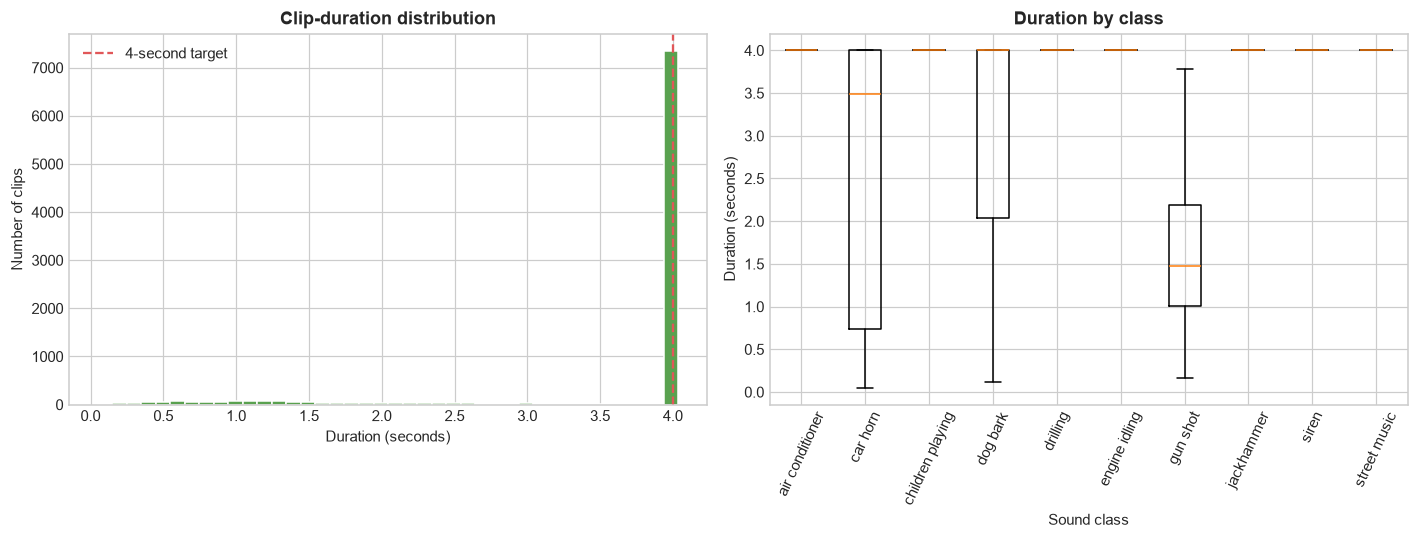

,sample_count,minimum,mean,median,maximum
class_name,,,,,
air_conditioner,1000,2.040,3.995,4.000,4.000
car_horn,429,0.050,2.456,3.490,4.000
children_playing,1000,1.048,3.962,4.000,4.037
dog_bark,1000,0.120,3.148,4.000,4.000
drilling,1000,0.417,3.546,4.000,4.008
engine_idling,1000,0.767,3.936,4.000,4.000
gun_shot,374,0.166,1.648,1.473,4.000
jackhammer,1000,0.390,3.611,4.000,4.000
siren,929,0.260,3.910,4.000,4.000


**Observation.** Durations range from **0.050** to **4.037 seconds**, with mean **3.608** and median **4.000 seconds**. Approximately **16.0%** of clips are shorter than four seconds and therefore receive trailing zero padding.

In [6]:
durations = inventory['audio_duration_seconds'].dropna()
target_duration = float(audio_settings['clip_duration_seconds'])
figure, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(durations, bins=40, color='#59A14F', edgecolor='white')
axes[0].axvline(target_duration, color='#E15759', linestyle='--', label='4-second target')
axes[0].set(title='Clip-duration distribution', xlabel='Duration (seconds)', ylabel='Number of clips')
axes[0].legend()

duration_by_class = [
    inventory.loc[inventory['class_name'] == class_name, 'audio_duration_seconds'].dropna()
    for class_name in ordered_classes
]
axes[1].boxplot(duration_by_class, tick_labels=[name.replace('_', ' ') for name in ordered_classes], showfliers=False)
axes[1].set(title='Duration by class', xlabel='Sound class', ylabel='Duration (seconds)')
axes[1].tick_params(axis='x', rotation=65)
figure.tight_layout()
save_figure(figure, '03_duration_distribution.png')
plt.show()

duration_summary = inventory.groupby('class_name')['audio_duration_seconds'].agg(
    sample_count='count', minimum='min', mean='mean', median='median', maximum='max'
).reindex(ordered_classes)
duration_summary.to_csv(METRIC_DIRECTORY / 'duration_summary_by_class.csv')
short_fraction = float((durations < target_duration - 1e-3).mean())
display(duration_summary.round(3))
display(Markdown(
    '**Observation.** Durations range from **{minimum:.3f}** to **{maximum:.3f} seconds**, with mean **{mean:.3f}** and median **{median:.3f} seconds**. Approximately **{short_fraction:.1%}** of clips are shorter than four seconds and therefore receive trailing zero padding.'.format(minimum=durations.min(), maximum=durations.max(), mean=durations.mean(), median=durations.median(), short_fraction=short_fraction)
))

## 6. Recording characteristics

Different source sample rates and channel counts justify resampling and mono conversion before feature extraction.

Saved: results\figures\eda\04_recording_characteristics.png


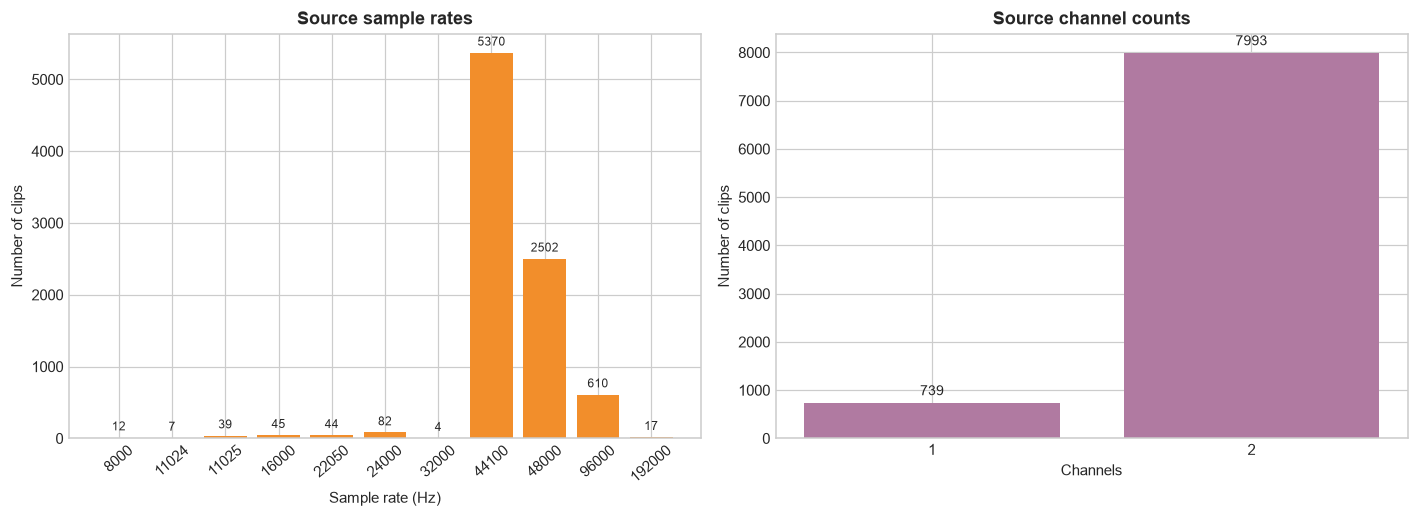

**Observation.** Source rates include **8,000, 11,024, 11,025, 16,000, 22,050, 24,000, 32,000, 44,100, 48,000, 96,000, 192,000 Hz**, and both mono and stereo clips occur. A fixed 22,050 Hz mono representation is therefore necessary for consistent model input rather than merely a convenience.

In [7]:
sample_rate_counts = inventory['sample_rate'].dropna().astype(int).value_counts().sort_index()
channel_counts = inventory['channels'].dropna().astype(int).value_counts().sort_index()
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
rate_bars = axes[0].bar(sample_rate_counts.index.astype(str), sample_rate_counts.values, color='#F28E2B')
axes[0].bar_label(rate_bars, padding=3, fontsize=8)
axes[0].set(title='Source sample rates', xlabel='Sample rate (Hz)', ylabel='Number of clips')
axes[0].tick_params(axis='x', rotation=40)
channel_bars = axes[1].bar(channel_counts.index.astype(str), channel_counts.values, color='#B07AA1')
axes[1].bar_label(channel_bars, padding=3, fontsize=9)
axes[1].set(title='Source channel counts', xlabel='Channels', ylabel='Number of clips')
figure.tight_layout()
save_figure(figure, '04_recording_characteristics.png')
plt.show()

recording_characteristics = pd.concat(
    [sample_rate_counts.rename('sample_rate_count'), channel_counts.rename('channel_count')],
    axis=1,
)
sample_rate_list = ', '.join(f'{value:,}' for value in sample_rate_counts.index)
display(Markdown(
    '**Observation.** Source rates include **{sample_rates} Hz**, and both mono and stereo clips occur. A fixed 22,050 Hz mono representation is therefore necessary for consistent model input rather than merely a convenience.'.format(sample_rates=sample_rate_list)
))

## 7. Deterministic representative samples

For each class, the selected example is the clip whose duration is closest to that class's median. This deterministic rule avoids choosing only unusually long or short examples.

In [8]:
representative_rows = []
for class_name in ordered_classes:
    candidates = inventory.loc[
        (inventory['class_name'] == class_name) & (inventory['readable'] == True)
    ].copy()
    class_median = candidates['audio_duration_seconds'].median()
    candidates['distance_from_median'] = (candidates['audio_duration_seconds'] - class_median).abs()
    selected = candidates.sort_values(['distance_from_median', 'sample_id']).iloc[0]
    representative_rows.append(selected)
representative_samples = pd.DataFrame(representative_rows).reset_index(drop=True)
representative_samples[
    ['sample_id', 'class_name', 'fold', 'audio_duration_seconds', 'sample_rate', 'channels']
].to_csv(METRIC_DIRECTORY / 'representative_samples.csv', index=False)
display(representative_samples[
    ['sample_id', 'class_name', 'fold', 'audio_duration_seconds', 'sample_rate', 'channels']
])

preprocessor = AudioPreprocessor(audio_settings).eval()
log_mel_settings = audio_settings['log_mel']
mfcc_extractor = MFCCFeatureExtractor(
    sample_rate=int(audio_settings['sample_rate']),
    n_mfcc=int(audio_settings['mfcc']['n_mfcc']),
    n_fft=int(log_mel_settings['n_fft']),
    win_length=int(log_mel_settings['win_length']),
    hop_length=int(log_mel_settings['hop_length']),
    n_mels=int(log_mel_settings['n_mels']),
    f_min=float(log_mel_settings['f_min']),
    f_max=log_mel_settings['f_max'],
    power=float(log_mel_settings['power']),
    center=bool(log_mel_settings['center']),
    pad_mode=str(log_mel_settings['pad_mode']),
    mel_scale=str(log_mel_settings['mel_scale']),
)

representatives = {}
with torch.inference_mode():
    for row in representative_samples.itertuples(index=False):
        loaded_audio = load_audio(Path(row.file_path))
        processed_audio = preprocessor(loaded_audio.waveform, loaded_audio.sample_rate, training=False)
        mfcc = mfcc_extractor(processed_audio.waveform)
        representatives[row.class_name] = {
            'sample_id': row.sample_id,
            'waveform': processed_audio.waveform.squeeze(0).cpu(),
            'log_mel': processed_audio.features.squeeze(0).cpu(),
            'mfcc': mfcc.squeeze(0).cpu(),
        }
print(f'Prepared {len(representatives)} deterministic class examples.')

,sample_id,class_name,fold,audio_duration_seconds,sample_rate,channels
0,100852-0-0-0.wav,air_conditioner,5,4.000000,44100,2
1,187356-1-3-0.wav,car_horn,4,3.490000,96000,2
2,100263-2-0-117.wav,children_playing,5,4.000000,44100,2
3,100652-3-0-0.wav,dog_bark,2,4.000000,44100,2
4,103199-4-0-0.wav,drilling,3,4.000000,44100,2
5,102857-5-0-0.wav,engine_idling,10,4.000000,44100,2
6,135526-6-0-0.wav,gun_shot,3,1.475397,44100,2
7,103074-7-0-0.wav,jackhammer,1,4.000000,48000,2
8,102853-8-0-0.wav,siren,7,4.000000,44100,2
9,101848-9-0-0.wav,street_music,7,4.000000,44100,2


Prepared 10 deterministic class examples.


## 8. Waveforms across all classes

Waveforms show amplitude over time. They reveal temporal sparsity and intensity, but do not directly separate frequencies.

Saved: results\figures\eda\05_representative_waveforms.png


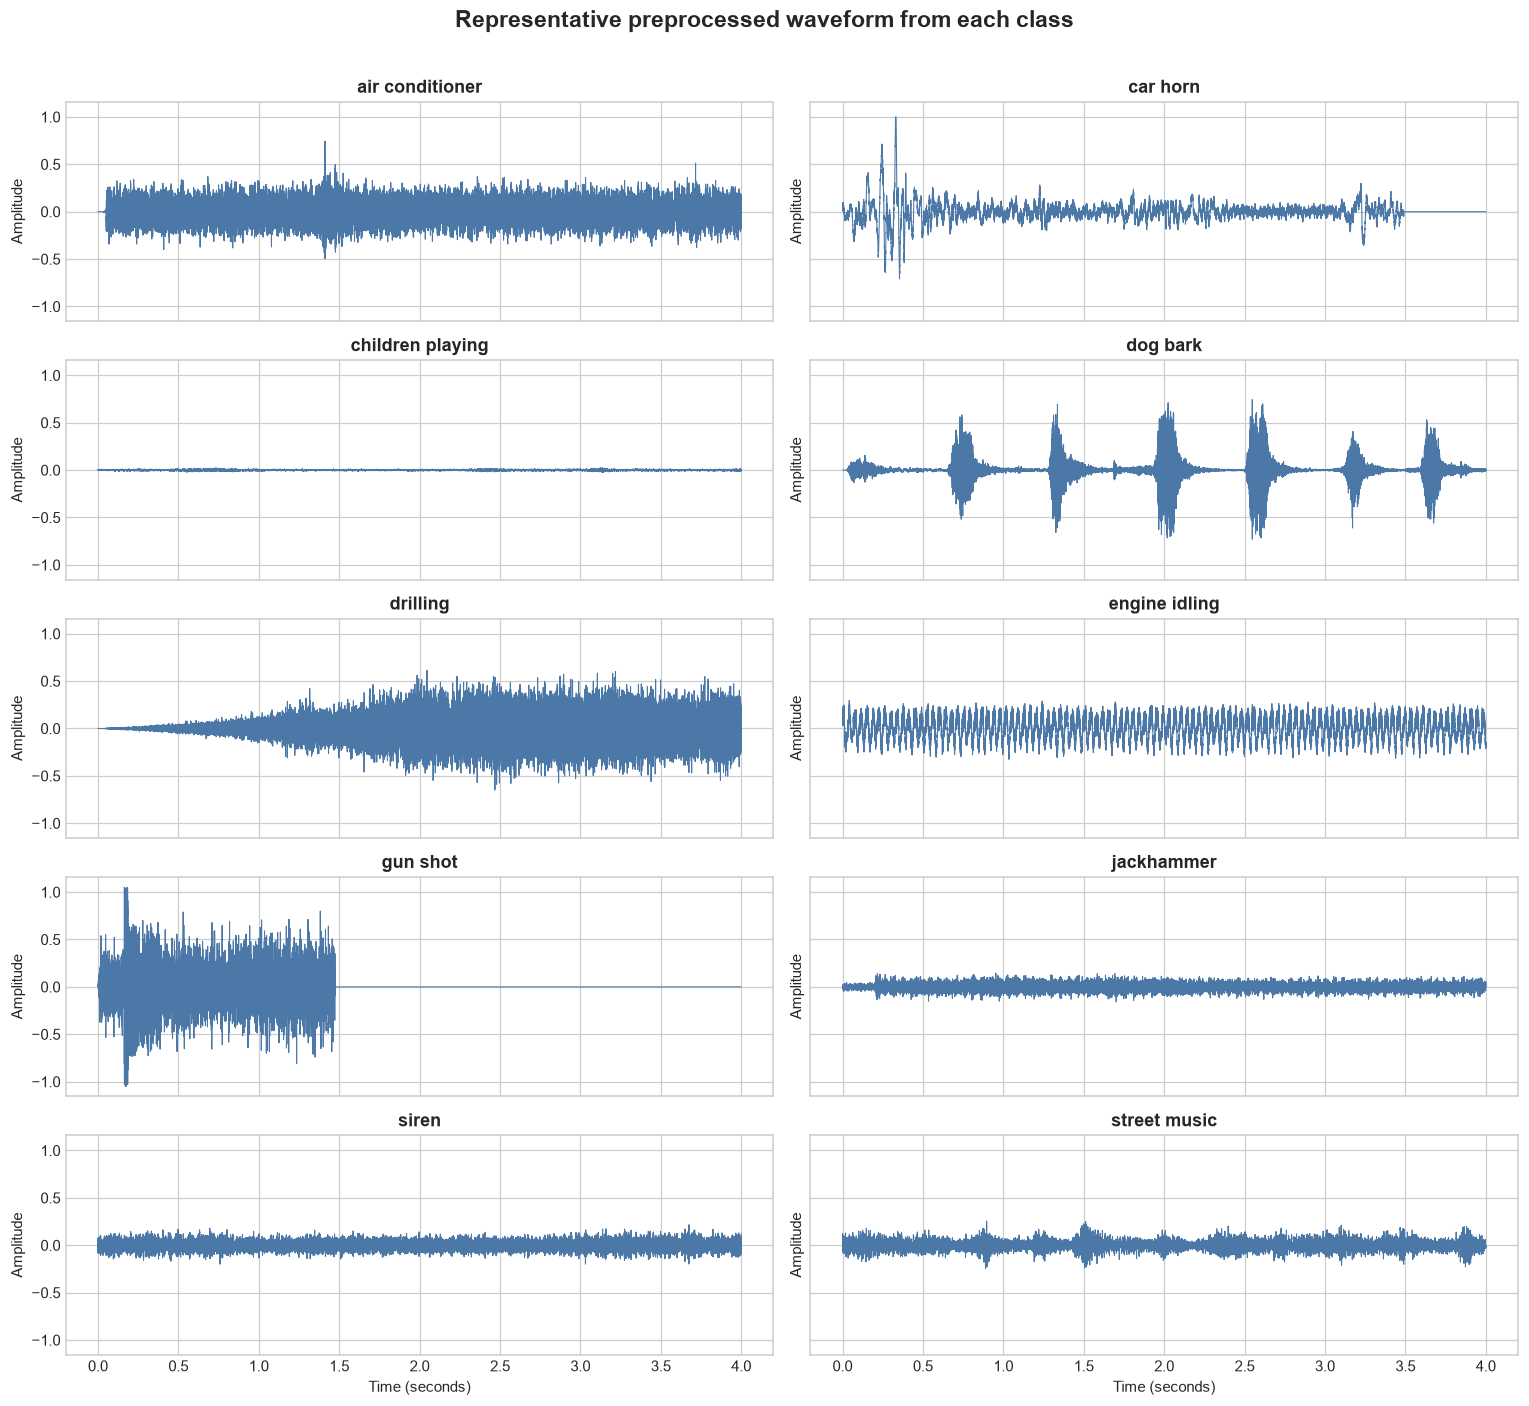

**Observation.** Temporal envelopes differ substantially across classes. Impulsive events such as gun shots and dog barks occupy short regions, while engine idling and air conditioning tend to be more sustained. Zero-valued tails visible in shorter examples are produced by the documented padding policy.

In [9]:
target_sample_rate = int(audio_settings['sample_rate'])
time_axis = np.arange(preprocessor.target_num_frames) / target_sample_rate
figure, axes = plt.subplots(5, 2, figsize=(14, 13), sharex=True, sharey=True)
for axis, class_name in zip(axes.flat, ordered_classes):
    example = representatives[class_name]
    axis.plot(time_axis, example['waveform'].numpy(), color='#4C78A8', linewidth=0.7)
    axis.set_title(class_name.replace('_', ' '))
    axis.set_ylabel('Amplitude')
for axis in axes[-1, :]:
    axis.set_xlabel('Time (seconds)')
figure.suptitle('Representative preprocessed waveform from each class', fontsize=15, fontweight='bold')
figure.tight_layout(rect=[0, 0, 1, 0.97])
save_figure(figure, '05_representative_waveforms.png')
plt.show()
display(Markdown(
    '**Observation.** Temporal envelopes differ substantially across classes. Impulsive events such as gun shots and dog barks occupy short regions, while engine idling and air conditioning tend to be more sustained. Zero-valued tails visible in shorter examples are produced by the documented padding policy.'
))

## 9. Log-Mel spectrograms across all classes

Log-Mel features expose how energy changes across perceptually spaced frequency bands. These standardized tensors are the primary inputs to the CNN, CRNN, and ResNet18 models.

Saved: results\figures\eda\06_representative_log_mel.png


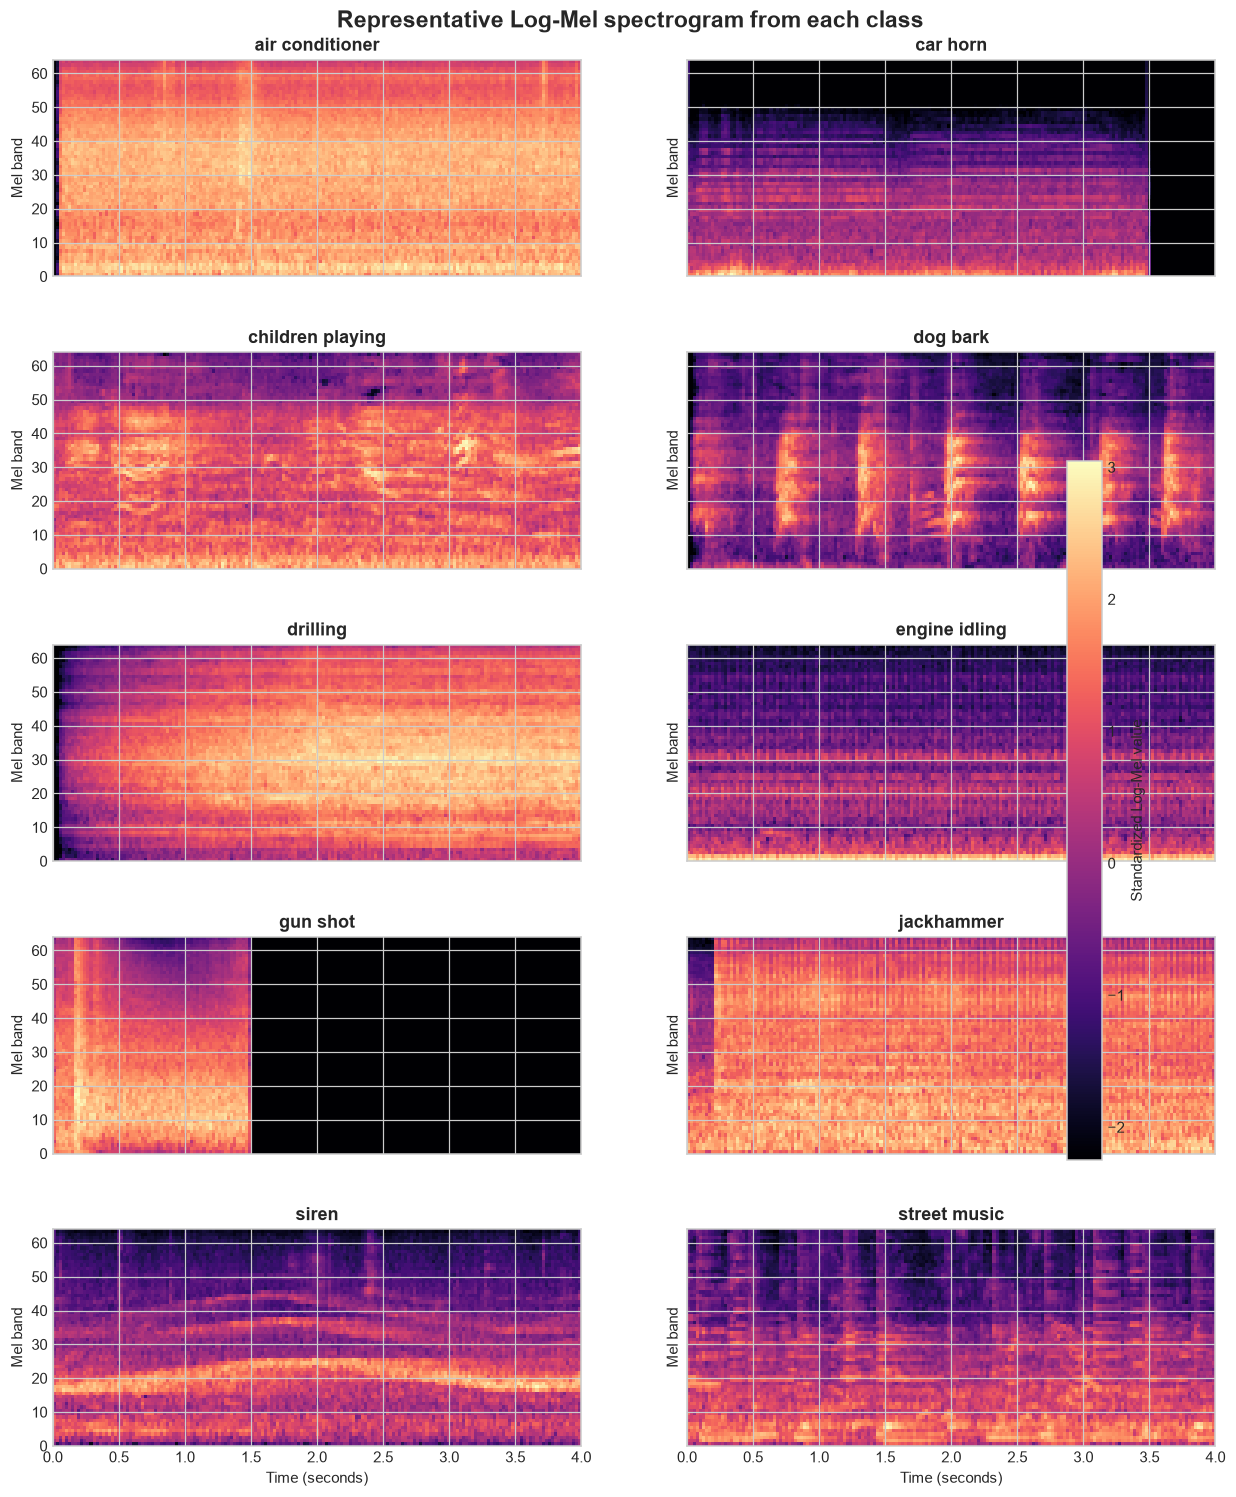

**Observation.** Classes contain visibly different time-frequency structure: sustained mechanical sounds form longer horizontal patterns, while short events produce compact broadband regions. Considerable within-dataset diversity still means these examples are descriptive rather than class templates.

In [10]:
figure, axes = plt.subplots(5, 2, figsize=(14, 15), sharex=True, sharey=True)
last_image = None
for axis, class_name in zip(axes.flat, ordered_classes):
    last_image = axis.imshow(
        representatives[class_name]['log_mel'].numpy(),
        origin='lower',
        aspect='auto',
        cmap='magma',
        extent=[0, target_duration, 0, log_mel_settings['n_mels']],
    )
    axis.set_title(class_name.replace('_', ' '))
    axis.set_ylabel('Mel band')
for axis in axes[-1, :]:
    axis.set_xlabel('Time (seconds)')
figure.colorbar(last_image, ax=axes.ravel().tolist(), shrink=0.55, label='Standardized Log-Mel value')
figure.suptitle('Representative Log-Mel spectrogram from each class', fontsize=15, fontweight='bold')
figure.subplots_adjust(top=0.95, right=0.88, hspace=0.35)
save_figure(figure, '06_representative_log_mel.png')
plt.show()
display(Markdown(
    '**Observation.** Classes contain visibly different time-frequency structure: sustained mechanical sounds form longer horizontal patterns, while short events produce compact broadband regions. Considerable within-dataset diversity still means these examples are descriptive rather than class templates.'
))

## 10. Detailed waveform, Log-Mel, and MFCC view

MFCCs compact the log-Mel spectrum using a discrete cosine transform. They are useful for exploratory comparison and a potential classical baseline, while Log-Mel remains the main deep-learning representation.

Saved: results\figures\eda\07_waveform_logmel_mfcc.png


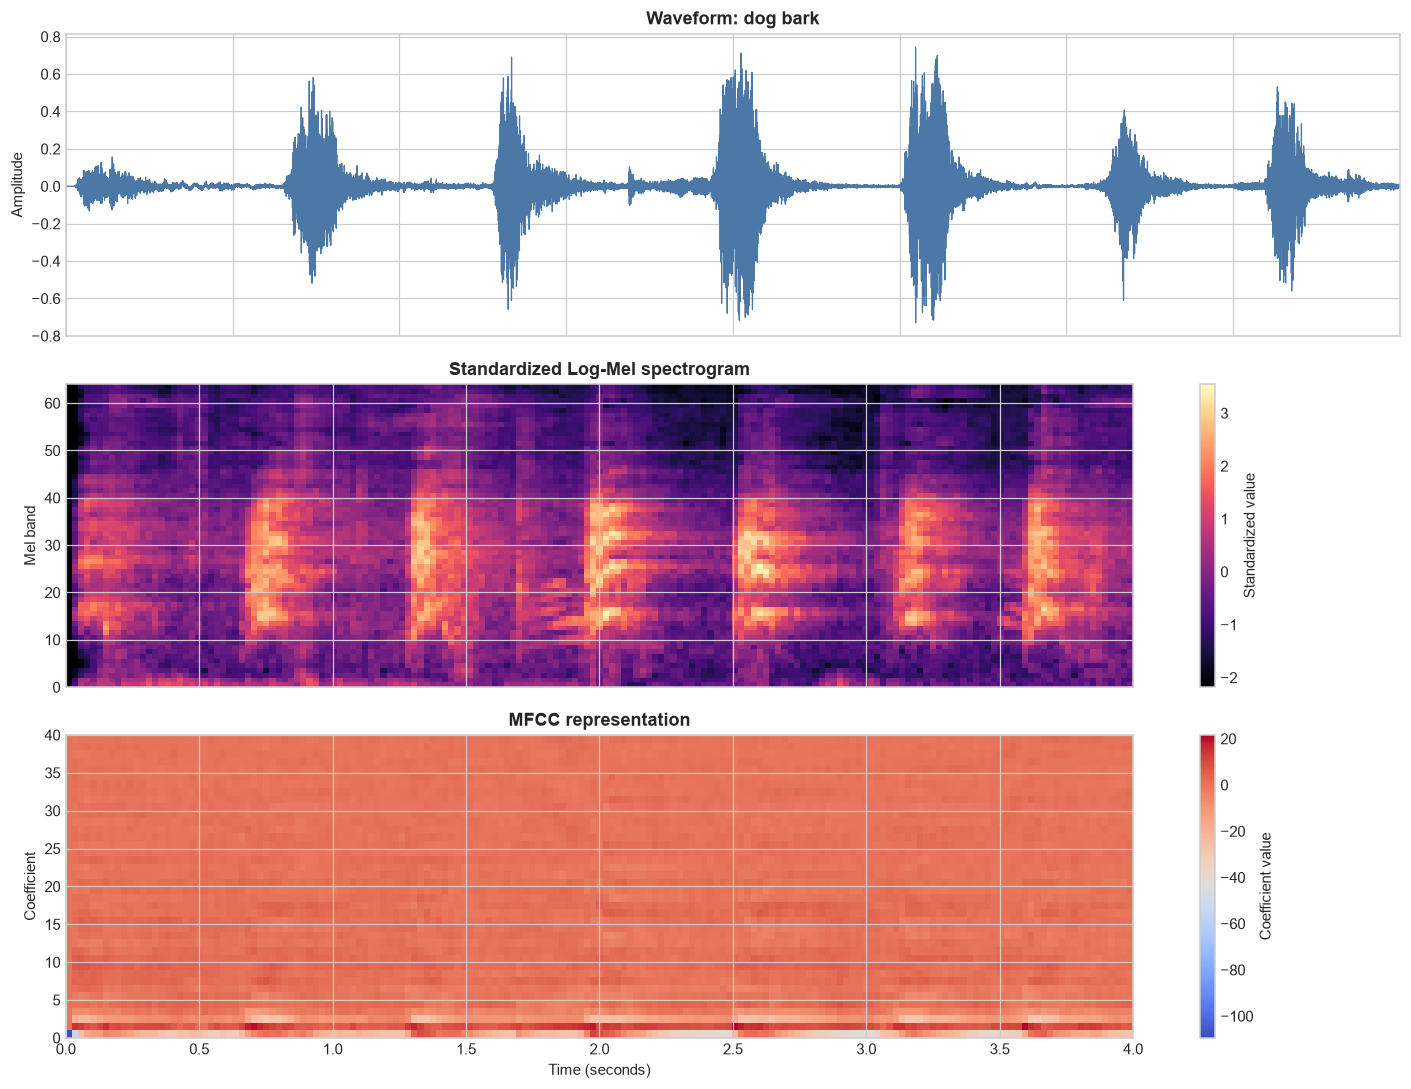

**Observation.** The waveform locates the event in time, the Log-Mel view retains local frequency-band detail, and MFCCs provide a more compact spectral-envelope description. This information loss is acceptable for a classical baseline but is why the neural models will consume Log-Mel tensors.

In [11]:
focus_class = 'dog_bark' if 'dog_bark' in representatives else ordered_classes[0]
focus_example = representatives[focus_class]
figure, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
axes[0].plot(time_axis, focus_example['waveform'].numpy(), color='#4C78A8', linewidth=0.8)
axes[0].set(title='Waveform: {}'.format(focus_class.replace('_', ' ')), ylabel='Amplitude')
log_image = axes[1].imshow(
    focus_example['log_mel'].numpy(), origin='lower', aspect='auto', cmap='magma',
    extent=[0, target_duration, 0, log_mel_settings['n_mels']]
)
axes[1].set(title='Standardized Log-Mel spectrogram', ylabel='Mel band')
figure.colorbar(log_image, ax=axes[1], label='Standardized value')
mfcc_image = axes[2].imshow(
    focus_example['mfcc'].numpy(), origin='lower', aspect='auto', cmap='coolwarm',
    extent=[0, target_duration, 0, audio_settings['mfcc']['n_mfcc']]
)
axes[2].set(title='MFCC representation', xlabel='Time (seconds)', ylabel='Coefficient')
figure.colorbar(mfcc_image, ax=axes[2], label='Coefficient value')
figure.tight_layout()
save_figure(figure, '07_waveform_logmel_mfcc.png')
plt.show()
display(Markdown(
    '**Observation.** The waveform locates the event in time, the Log-Mel view retains local frequency-band detail, and MFCCs provide a more compact spectral-envelope description. This information loss is acceptable for a classical baseline but is why the neural models will consume Log-Mel tensors.'
))

## 11. Conclusions and modeling implications

In [12]:
eda_summary = {
    'dataset_name': adapter.dataset_name,
    'total_samples': int(inspection_summary['total_samples']),
    'num_classes': int(inspection_summary['num_classes']),
    'missing_file_count': int(inspection_summary['missing_file_count']),
    'unreadable_file_count': int(inspection_summary['unreadable_file_count']),
    'minimum_duration_seconds': float(durations.min()),
    'maximum_duration_seconds': float(durations.max()),
    'mean_duration_seconds': float(durations.mean()),
    'median_duration_seconds': float(durations.median()),
    'fraction_shorter_than_target': short_fraction,
    'class_imbalance_ratio': float(imbalance_ratio),
    'sample_rates': [int(value) for value in sample_rate_counts.index],
    'channel_counts': {str(index): int(value) for index, value in channel_counts.items()},
    'split_counts': split_counts,
    'representative_sample_ids': {name: values['sample_id'] for name, values in representatives.items()},
    'figures': sorted(path.name for path in FIGURE_DIRECTORY.glob('*.png')),
}
with (METRIC_DIRECTORY / 'eda_summary.json').open('w', encoding='utf-8') as file_handle:
    json.dump(eda_summary, file_handle, indent=2, sort_keys=True)
    file_handle.write('\n')

display(Markdown(
    f'''### Main findings

1. **Dataset integrity:** all **{eda_summary['total_samples']:,}** files are present and readable.
2. **Class balance:** the largest-to-smallest class ratio is **{imbalance_ratio:.2f}:1**; report macro F1 and per-class metrics with accuracy.
3. **Leakage prevention:** retain the official fold split; never randomly redistribute individual clips across splits.
4. **Length normalization:** **{short_fraction:.1%}** of clips need padding to reach four seconds.
5. **Recording variation:** multiple sample rates and channel layouts validate the configured mono conversion and 22,050 Hz resampling.
6. **Representation:** Log-Mel exposes useful class-dependent time-frequency patterns and remains the primary neural-network input; MFCC is retained for EDA and a potential classical baseline.
7. **Research caution:** representative plots illustrate structure but do not establish separability. Model results must be evaluated over the complete held-out fold and later under controlled noise.

f'Structured outputs were saved under `{METRIC_DIRECTORY.relative_to(PROJECT_ROOT)}`; publication-ready figures were saved under `{FIGURE_DIRECTORY.relative_to(PROJECT_ROOT)}`.'
'''
))

### Main findings

1. **Dataset integrity:** all **8,732** files are present and readable.
2. **Class balance:** the largest-to-smallest class ratio is **2.67:1**; report macro F1 and per-class metrics with accuracy.
3. **Leakage prevention:** retain the official fold split; never randomly redistribute individual clips across splits.
4. **Length normalization:** **16.0%** of clips need padding to reach four seconds.
5. **Recording variation:** multiple sample rates and channel layouts validate the configured mono conversion and 22,050 Hz resampling.
6. **Representation:** Log-Mel exposes useful class-dependent time-frequency patterns and remains the primary neural-network input; MFCC is retained for EDA and a potential classical baseline.
7. **Research caution:** representative plots illustrate structure but do not establish separability. Model results must be evaluated over the complete held-out fold and later under controlled noise.

f'Structured outputs were saved under `results\metrics\eda`; publication-ready figures were saved under `results\figures\eda`.'
